# 06 — Y-Randomization

Validates model robustness by shuffling labels (Y) while keeping features (X) intact.
50 rounds per dataset.

Expected results (paper):
- Mean ACC ≈ 0.5 for both datasets
- Mean MCC ≈ 0.02 (3T3) and 0.01 (HEK293)

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, matthews_corrcoef
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

os.makedirs('../data/results', exist_ok=True)

N_ROUNDS = 50
RANDOM_STATE = 42


=== 3T3 ===


3T3 Y-rand: 100%|██████████| 50/50 [00:43<00:00,  1.15it/s]


  Mean ACC = 0.596 (expected ~0.5)
  Mean MCC = -0.021 (expected ~0.01–0.02)


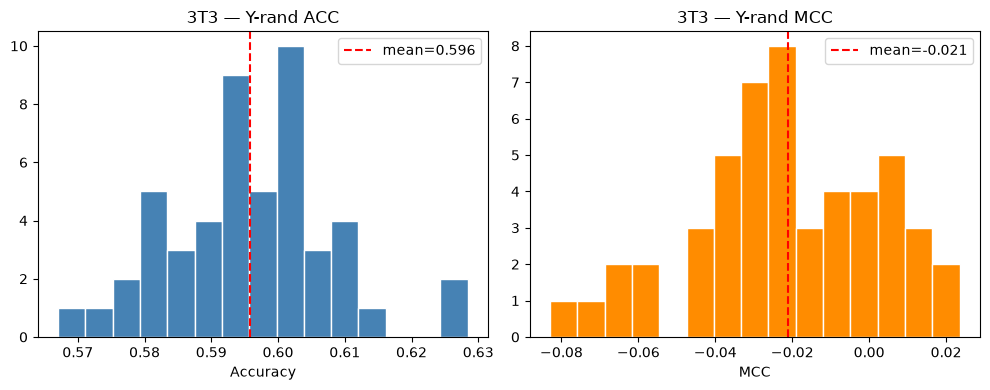


=== HEK293 ===


HEK293 Y-rand: 100%|██████████| 50/50 [00:46<00:00,  1.08it/s]

  Mean ACC = 0.574 (expected ~0.5)
  Mean MCC = -0.016 (expected ~0.01–0.02)


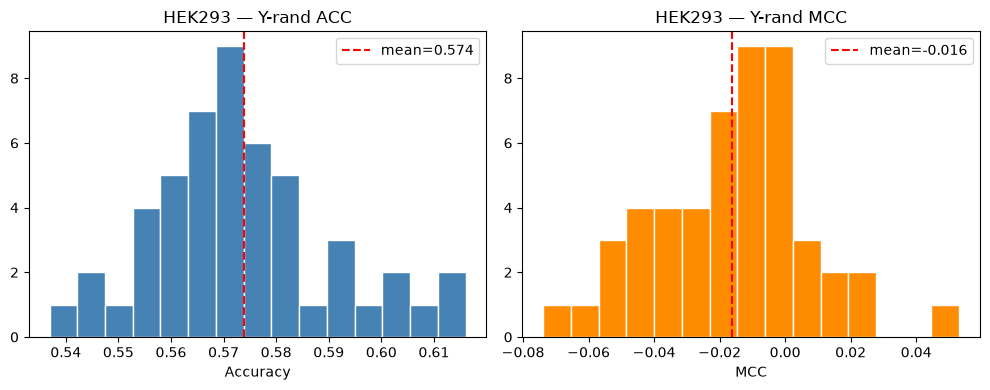

In [2]:
DATASETS = ['3T3', 'HEK293']
results_all = {}

for name in DATASETS:
    print(f'\n=== {name} ===')

    # Load train/test fingerprints
    fp_train_path = f'../data/fp/{name}_ecfp4_train.json'
    if os.path.exists(fp_train_path):
        with open(fp_train_path) as f:
            X_train = np.asarray(json.load(f))
        with open(f'../data/fp/{name}_y_train.json') as f:
            y_train = np.asarray(json.load(f))
        with open(f'../data/fp/{name}_ecfp4_test.json') as f:
            X_test = np.asarray(json.load(f))
        with open(f'../data/fp/{name}_y_test.json') as f:
            y_test = np.asarray(json.load(f))
    else:
        X_train = np.load(f'../data/splits/{name}_X_train.npy')
        y_train = np.load(f'../data/splits/{name}_y_train.npy')
        X_test  = np.load(f'../data/splits/{name}_X_test.npy')
        y_test  = np.load(f'../data/splits/{name}_y_test.npy')

    # Load best params from notebook 04 (or use defaults)
    params_path = f'../models/{name}_best_params.json'
    if os.path.exists(params_path):
        with open(params_path) as f:
            best_params = json.load(f)
    else:
        best_params = {}  # use defaults

    acc_list, mcc_list = [], []

    for i in tqdm(range(N_ROUNDS), desc=f'{name} Y-rand'):
        rng = np.random.RandomState(RANDOM_STATE + i)
        y_shuffled = rng.permutation(y_train)

        clf = LGBMClassifier(
            class_weight='balanced',
            random_state=RANDOM_STATE,
            verbosity=-1,
            **best_params,
        )
        clf.fit(X_train, y_shuffled)

        y_pred = clf.predict(X_test)
        acc_list.append(accuracy_score(y_test, y_pred))
        mcc_list.append(matthews_corrcoef(y_test, y_pred))

    mean_acc = np.mean(acc_list)
    mean_mcc = np.mean(mcc_list)
    print(f'  Mean ACC = {mean_acc:.3f} (expected ~0.5)')
    print(f'  Mean MCC = {mean_mcc:.3f} (expected ~0.01–0.02)')

    results_all[name] = {'acc': acc_list, 'mcc': mcc_list}

    # Plot distribution
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].hist(acc_list, bins=15, color='steelblue', edgecolor='white')
    axes[0].axvline(mean_acc, color='red', linestyle='--', label=f'mean={mean_acc:.3f}')
    axes[0].set_xlabel('Accuracy'); axes[0].set_title(f'{name} — Y-rand ACC')
    axes[0].legend()

    axes[1].hist(mcc_list, bins=15, color='darkorange', edgecolor='white')
    axes[1].axvline(mean_mcc, color='red', linestyle='--', label=f'mean={mean_mcc:.3f}')
    axes[1].set_xlabel('MCC'); axes[1].set_title(f'{name} — Y-rand MCC')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(f'../data/results/{name}_y_randomization.png', dpi=150)
    plt.show()

    pd.DataFrame({'ACC': acc_list, 'MCC': mcc_list}).to_csv(
        f'../data/results/{name}_y_randomization.csv', index=False)